In [1]:
import time
import h5py

import jax
import jax.numpy as jnp
import numpy as np

import cantera as ct
from pyrometheus.codegen.python import PythonCodeGenerator as pyro

from pyrometheus.flamelets.make_pyro import make_pyro_object
from pyrometheus.flamelets.domain import DomainConfig, Domain
from pyrometheus.flamelets.state import FlameletState, _state_to_array, _array_to_state
from pyrometheus.flamelets.equations import FlameletEquations
from pyrometheus.flamelets.solver import FlameletSolver
from pyrometheus.flamelets.utils import bell_profile, stoichiometric_mixture_fraction

from itertools import product
from matplotlib import pyplot as plt

In [2]:

ct_dir = './'
ct_file = 'sandiego.yaml'
sol = ct.Solution(ct_dir + ct_file)
sol.transport_model = 'unity-Lewis-number'

pyro_gas = make_pyro_object(
    pyro.get_thermochem_class(sol),
    jnp
)

In [3]:
temp_ox = 500
temp_fu = 300
pres = ct.one_atm

sol.TPX = temp_ox, pres, 'O2:0.21, N2:0.79'
y_ox = sol.Y
h_ox = sol.enthalpy_mass

sol.TPX = temp_fu, pres, f'H2:0.5, N2:0.5'
y_fu = sol.Y
h_fu = sol.enthalpy_mass

z_st = stoichiometric_mixture_fraction(sol, y_ox, y_fu)

print(f'Z_st = {z_st:.3f}')



Z_st = 0.304


In [4]:
def new_dissipation_profile(z, z_st, val_st, bval):
    profile = val_st * bell_profile(z) / bell_profile(z_st)
    for ib in (0, -1):
        profile = profile.at[ib].set(bval)

    return profile

In [5]:
config = {}
config['max_attempts'] = 10
config['bdf'] = {}
config['bdf']['maxsteps'] = 10
config['bdf']['time_step'] = 1e-5
config['bdf']['newton'] = {}
config['bdf']['newton']['maxiter'] = 20
config['bdf']['newton']['tol'] = 1e-9
config['newton'] = {}
config['newton']['maxiter'] = 10
config['newton']['tol'] = 1e-8

In [6]:
domain_config = DomainConfig(
    num_x=101, x_l=0, x_r=1,
)
domain = Domain(domain_config)
solver = FlameletSolver(domain, pyro_gas, (y_ox, y_fu))

mixture_fraction = jnp.array(domain.x)
num_z = len(mixture_fraction)

In [7]:
linear_enthalpy = h_ox + (h_fu - h_ox) * mixture_fraction
linear_mass_frac = (
    (y_ox + (y_fu - y_ox) * mixture_fraction[:, None]).T
)
temp_linear = pyro_gas.get_temperature_from_enthalpy(
    linear_enthalpy,
    linear_mass_frac,
    temp_ox + (temp_fu - temp_ox) *mixture_fraction
)
state_linear = FlameletState(
    enthalpy=linear_enthalpy,
    mass_fractions=linear_mass_frac
)    
state_equil = FlameletState(
    enthalpy=linear_enthalpy,
    mass_fractions=linear_mass_frac
)
temp_equil = jnp.zeros(num_z, dtype=jnp.float64)
for i in range(num_z):
    sol.HPY = (
        state_equil.enthalpy[i],
        pres,
        state_equil.mass_fractions[:, i]
    )
    sol.equilibrate('HP')
    temp_equil = temp_equil.at[i].set(sol.T)
    state_equil.mass_fractions = (
        state_equil.mass_fractions.at[:, i].set(sol.Y)
    )

In [8]:
# Warm up the solvers first
t_wmp = time.time()
wmp = solver.warmup(
    'flamelet_newton_step',
    state_equil,    
    new_dissipation_profile(
        mixture_fraction, z_st,
        100, 2 * domain.jac[0]**2
    ),
    new_dissipation_profile(
        mixture_fraction, z_st,
        0, 0
    ),
    temp_equil,
    pres,
    h_ox,
    h_fu
)
wmp.enthalpy.block_until_ready()
print(f'Warm up time: {(time.time() - t_wmp):.4e} s')

t_wmp = time.time()
wmp, _, _ = solver.warmup(
    'flamelet_time_step',
    state_equil,
    config['bdf']['newton']['maxiter'],
    config['bdf']['newton']['tol'],    
    state_equil,
    config['bdf']['time_step'],    
    new_dissipation_profile(
        mixture_fraction, z_st,
        100, 2 * domain.jac[0]**2
    ),
    new_dissipation_profile(
        mixture_fraction, z_st,
        0, 0
    ),
    temp_equil,
    pres,
    h_ox,
    h_fu
)
wmp.enthalpy.block_until_ready()
print(f'Warm up time: {(time.time() - t_wmp):.4e} s')

# Get an intermediate solution
diss_rate = new_dissipation_profile(
    mixture_fraction, z_st,
    100, 2 * domain.jac[0]**2
)
viscous_diss = new_dissipation_profile(
    mixture_fraction, z_st,
    0, 0
)

t_run = time.time()
state_base, temp_base = solver.solve(
config['newton']['maxiter'],
    config['newton']['tol'],
    config['bdf']['newton']['maxiter'],
    config['bdf']['newton']['tol'], 
    config['bdf']['time_step'],
    config['bdf']['maxsteps'],
    False,
    config['max_attempts'],
    diss_rate,
    viscous_diss,
    temp_equil,
    pres,
    h_ox,
    h_fu,
    state_equil
)
state_base.enthalpy.block_until_ready()
print(f'Run time: {(time.time() - t_run):.4e} s')

# Get the baseline guess
diss_rate = new_dissipation_profile(
    mixture_fraction, z_st,
    1000, 2 * domain.jac[0]**2
)
viscous_diss = new_dissipation_profile(
    mixture_fraction, z_st,
    0, 0
)

t_run = time.time()
state_base, temp_base = solver.solve(
config['newton']['maxiter'],
    config['newton']['tol'],
    config['bdf']['newton']['maxiter'],
    config['bdf']['newton']['tol'], 
    config['bdf']['time_step'],
    config['bdf']['maxsteps'],
    False,
    config['max_attempts'],
    diss_rate,
    viscous_diss,
    temp_base,
    pres,
    h_ox,
    h_fu,
    state_base
)
state_base.enthalpy.block_until_ready()
print(f'Run time: {(time.time() - t_run):.4e} s')

Warm up time: 3.9552e+00 s
Warm up time: 5.0284e+00 s
Attempt 0 of BDF time marching
BDF time step 0: time: 4.0820e-03 s, T_max = 2024.005 K 
BDF time step 1: time: 4.4024e-03 s, T_max = 1995.429 K 
BDF time step 2: time: 4.3340e-03 s, T_max = 1962.204 K 
BDF time step 3: time: 5.1761e-03 s, T_max = 1942.950 K 
BDF time step 4: time: 4.2722e-03 s, T_max = 1923.554 K 
BDF time step 5: time: 4.3421e-03 s, T_max = 1912.424 K 
BDF time step 6: time: 4.3471e-03 s, T_max = 1901.378 K 
BDF time step 7: time: 4.2198e-03 s, T_max = 1894.576 K 
BDF time step 8: time: 4.1583e-03 s, T_max = 1887.830 K 
BDF time step 9: time: 4.2350e-03 s, T_max = 1883.539 K 
BDF Time march: T_max = 1883.539 K
Newton iteration 0: time: 1.2093e-03 s, |v| = 1.0434e-02
Newton iteration 1: time: 1.2457e-03 s, |v| = 4.5838e-03
Newton iteration 2: time: 1.1570e-03 s, |v| = 1.6754e-03
Newton iteration 3: time: 1.0509e-03 s, |v| = 4.9009e-04
Newton iteration 4: time: 1.0381e-03 s, |v| = 8.9558e-05
Newton iteration 5: time:

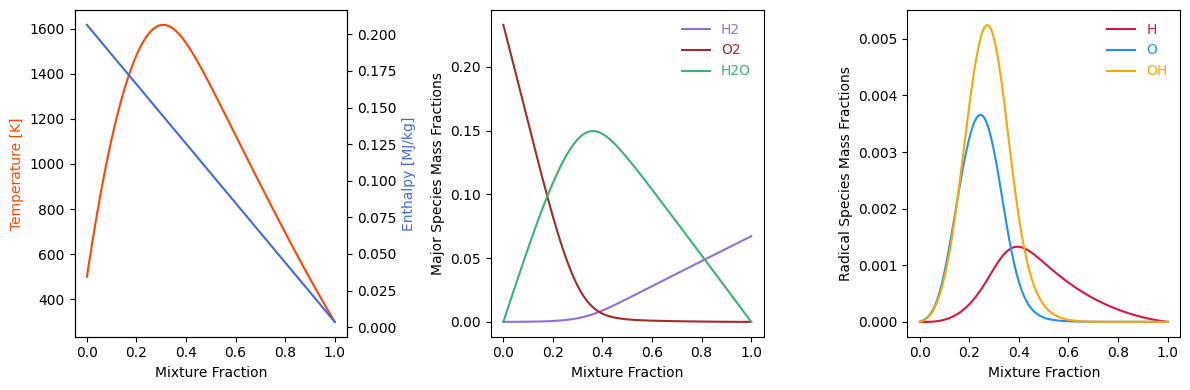

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax_l = ax[0]
ax_r = ax_l.twinx()
ax_l.plot(mixture_fraction, temp_base, color='orangered')
ax_r.plot(mixture_fraction, state_base.enthalpy * 1e-6, color='royalblue')

ax[1].plot(mixture_fraction, state_base.mass_fractions[0], color='mediumpurple', label='H2')
ax[1].plot(mixture_fraction, state_base.mass_fractions[2], color='brown', label='O2')
ax[1].plot(mixture_fraction, state_base.mass_fractions[-2], color='mediumseagreen', label='H2O')
ax[1].legend(frameon=False, labelcolor='linecolor')

ax[2].plot(mixture_fraction, state_base.mass_fractions[1], color='crimson', label='H')
ax[2].plot(mixture_fraction, state_base.mass_fractions[3], color='dodgerblue', label='O')
ax[2].plot(mixture_fraction, state_base.mass_fractions[4], color='orange', label='OH')
ax[2].legend(frameon=False, labelcolor='linecolor')

ax_l.set_ylabel('Temperature [K]', color='orangered')
ax_r.set_ylabel('Enthalpy [MJ/kg]', color='royalblue')

ax[1].set_ylabel('Major Species Mass Fractions')
ax[2].set_ylabel('Radical Species Mass Fractions')
for a in ax:
    a.set_xlabel('Mixture Fraction')

plt.tight_layout()
plt.show()